# Optimization (Projet 6)

## Section Imports

In [ ]:
import pandas as pd
import numpy as np
import gc
import time
import matplotlib.pyplot as plt
import optuna
import mlflow
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score, f1_score
import json

import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('mlflow').setLevel(logging.ERROR)
optuna.logging.set_verbosity(optuna.logging.WARNING)


## Config MLFlow

In [2]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("home_credit_scoring")

mlflow.lightgbm.autolog(log_models=False)


## Chargement Data (../input/data_clean.parquet)

In [3]:
df = pd.read_parquet('../input/data_clean.parquet')
train_df = df[df['TARGET'].notnull()]
test_df  = df[df['TARGET'].isnull()]
print(f"Train: {train_df.shape}, Test: {test_df.shape}")

feats = [f for f in train_df.columns if f not in ['TARGET', 'SK_ID_CURR']]


Train: (307507, 797), Test: (48744, 797)


## Fonctions format_duration et business_costs

In [ ]:
def format_duration(seconds):
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = int(seconds % 60)
    parts = []
    if h > 0: parts.append(f"{h} hr{'s' if h > 1 else ''}")
    if m > 0: parts.append(f"{m} mn{'s' if m > 1 else ''}")
    parts.append(f"{s} sec{'s' if s > 1 else ''}")
    return ' '.join(parts)

def business_cost(y_true, y_pred, threshold=0.5):
    y_class = (y_pred >= threshold).astype(int)
    fn = ((y_true == 1) & (y_class == 0)).sum()
    fp = ((y_true == 0) & (y_class == 1)).sum()
    return 10 * fn + 1 * fp


## Fonction Objective  / Optuna Trials

In [ ]:

def objective(trial):
    t0 = time.time()
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 500, 1500),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 60),
        'max_depth':        trial.suggest_int('max_depth', 6, 10),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0),
        'subsample':        trial.suggest_float('subsample', 0.7, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.01, 0.2, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.01, 0.3, log=True),
        'min_split_gain':   trial.suggest_float('min_split_gain', 0.0, 0.1),
        'min_child_weight': trial.suggest_float('min_child_weight', 20.0, 60.0),
        'class_weight':      'balanced',
        'random_state':      1001,
        'n_jobs':            -1,
        'verbose':           -1,
        'metric':            'auc',
    }

    folds    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=1001)
    oof_preds = np.zeros(opt_df.shape[0])

    with mlflow.start_run(run_name=f"lgbm_optuna_trial_{trial.number}", nested=True):
        mlflow.log_params(params)

        for train_idx, valid_idx in folds.split(opt_df[feats], opt_df['TARGET']):
            train_x = opt_df[feats].iloc[train_idx]
            train_y = opt_df['TARGET'].iloc[train_idx]
            valid_x = opt_df[feats].iloc[valid_idx]
            valid_y = opt_df['TARGET'].iloc[valid_idx]

            clf = LGBMClassifier(**params)
            clf.fit(train_x, train_y,
                    eval_set=[(valid_x, valid_y)],
                    callbacks=[lgb.early_stopping(100, verbose=False)])

            oof_preds[valid_idx] = clf.predict_proba(valid_x)[:, 1]

            del train_x, train_y, valid_x, valid_y, clf
            gc.collect()

        cost = business_cost(opt_df['TARGET'], oof_preds)
        auc  = roc_auc_score(opt_df['TARGET'], oof_preds)

        mlflow.log_metric('auc_overall', auc)
        mlflow.log_metric('cost_overall', cost)

    print(f"Trial {trial.number:3d} — AUC: {auc:.4f} | Cost: {cost:.0f} | Time: {format_duration(time.time() - t0)}")
    print(f"Tps restant estimé: {format_duration((time.time() - t00) / (trial.number + 1) * (N_TRIALS - trial.number - 1))}")
    return cost  # Optuna minimise le coût métier


## Train Dataset

In [ ]:
N_TRIALS   = 20    # nombre de trials Optuna
N_FOLDS    = 5     # folds pour la CV dans chaque trial
SAMPLE_FRAC = 0.2  # fraction du train pour accélérer l'optimisation (1.0 pour le dataset complet)

if SAMPLE_FRAC < 1.0:
    opt_df = train_df.groupby('TARGET', group_keys=False).apply(
        lambda x: x.sample(frac=SAMPLE_FRAC, random_state=1001)
    ).reset_index(drop=True)
    print(f"Train réduit pour Optuna: {opt_df.shape} | Ratio TARGET: {opt_df['TARGET'].mean():.4f}")
else:
    opt_df = train_df
    print(f"Train complet pour Optuna: {opt_df.shape}")



Train réduit pour Optuna: (61501, 797) | Ratio TARGET: 0.0807


## Main Optuna

In [6]:
t00 = time.time()

with mlflow.start_run(run_name="lgbm_optuna_study"):
    mlflow.set_tags({
        "infos": f"Optuna study LightGBM — {N_TRIALS} trials — SAMPLE_FRAC={SAMPLE_FRAC}",
        "n_trials": N_TRIALS,
        "sample_frac": SAMPLE_FRAC,
    })

    study = optuna.create_study(direction='minimize')  # minimiser le coût métier
    study.optimize(objective, n_trials=N_TRIALS)

    best_params = study.best_params
    best_cost   = study.best_value
    best_trial  = study.best_trial.number

    mlflow.log_params({f"best_{k}": v for k, v in best_params.items()})
    mlflow.log_metric('best_cost', best_cost)


print(f"\nOptuna terminé en {format_duration(time.time() - t00)}")
print(f"Best trial: {best_trial} — Cost: {best_cost:.0f}")
print(f"Best params: {best_params}")


Trial   0 — AUC: 0.7704 | Cost: 31490 | Time: 8 mns 25 secs
Tps restant estimé: 2 hrs 40 mns 15 secs
Trial   1 — AUC: 0.7687 | Cost: 31954 | Time: 13 mns 3 secs
Tps restant estimé: 3 hrs 13 mns 25 secs
Trial   2 — AUC: 0.7681 | Cost: 31512 | Time: 8 mns 33 secs
Tps restant estimé: 2 hrs 50 mns 14 secs
Trial   3 — AUC: 0.7701 | Cost: 31532 | Time: 6 mns 36 secs
Tps restant estimé: 2 hrs 26 mns 37 secs
Trial   4 — AUC: 0.7699 | Cost: 31399 | Time: 4 mns 38 secs
Tps restant estimé: 2 hrs 3 mns 52 secs
Trial   5 — AUC: 0.7697 | Cost: 31394 | Time: 4 mns 39 secs
Tps restant estimé: 1 hr 47 mns 12 secs
Trial   6 — AUC: 0.7704 | Cost: 31584 | Time: 4 mns 39 secs
Tps restant estimé: 1 hr 33 mns 59 secs
Trial   7 — AUC: 0.7695 | Cost: 31623 | Time: 4 mns 14 secs
Tps restant estimé: 1 hr 22 mns 16 secs
Trial   8 — AUC: 0.7673 | Cost: 32118 | Time: 4 mns 49 secs
Tps restant estimé: 1 hr 12 mns 56 secs
Trial   9 — AUC: 0.7693 | Cost: 31751 | Time: 6 mns 30 secs
Tps restant estimé: 1 hr 6 mns 11 se

## Optimisation du seuil métier

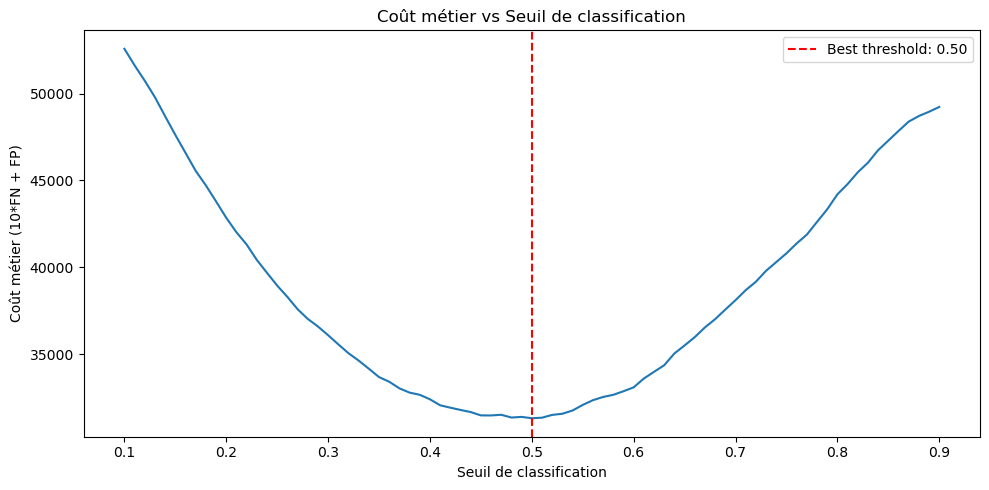

Best threshold: 0.50 — Cost: 31313
AUC OOF: 0.7712


In [11]:
# Ré-entraînement avec best_params sur opt_df pour obtenir les OOF predictions
folds     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=1001)
oof_preds = np.zeros(opt_df.shape[0])

best_lgbm_params = {
    **best_params,
    'class_weight': 'balanced',
    'random_state': 1001,
    'n_jobs': -1,
    'verbose': -1,
    'metric': 'auc',
}

for train_idx, valid_idx in folds.split(opt_df[feats], opt_df['TARGET']):
    train_x = opt_df[feats].iloc[train_idx]
    train_y = opt_df['TARGET'].iloc[train_idx]
    valid_x = opt_df[feats].iloc[valid_idx]
    valid_y = opt_df['TARGET'].iloc[valid_idx]

    clf = LGBMClassifier(**best_lgbm_params)
    clf.fit(train_x, train_y,
            eval_set=[(valid_x, valid_y)],
            callbacks=[lgb.early_stopping(100, verbose=False)])

    oof_preds[valid_idx] = clf.predict_proba(valid_x)[:, 1]

    del train_x, train_y, valid_x, valid_y, clf
    gc.collect()

# Courbe coût vs seuil
thresholds = np.arange(0.1, 0.91, 0.01)
costs      = [business_cost(opt_df['TARGET'], oof_preds, t) for t in thresholds]

best_threshold = thresholds[np.argmin(costs)]
best_cost_thr  = min(costs)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold: {best_threshold:.2f}')
plt.xlabel('Seuil de classification')
plt.ylabel('Coût métier (10*FN + FP)')
plt.title('Coût métier vs Seuil de classification')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_curve.png')
plt.show()

print(f"Best threshold: {best_threshold:.2f} — Cost: {best_cost_thr:.0f}")
print(f"AUC OOF: {roc_auc_score(opt_df['TARGET'], oof_preds):.4f}")


In [12]:
print(opt_df.index.min(), opt_df.index.max(), len(opt_df))

0 61500 61501


## Modèle final — Entraînement sur 100% du train + Model Registry

In [13]:
# Split 90/10 pour garder l'early stopping
from sklearn.model_selection import train_test_split

X_final_train, X_final_val, y_final_train, y_final_val = train_test_split(
    train_df[feats], train_df['TARGET'],
    test_size=0.2, random_state=1001, stratify=train_df['TARGET']
)

with mlflow.start_run(run_name="lgbm_final_model"):
    mlflow.set_tags({
        "infos": "Modèle final LightGBM avec best params Optuna",
        "best_threshold": best_threshold,
        "sample_frac_optuna": SAMPLE_FRAC,
    })
    mlflow.log_params(best_lgbm_params)

    final_clf = LGBMClassifier(**best_lgbm_params)
    final_clf.fit(
        X_final_train, y_final_train,
        eval_set=[(X_final_val, y_final_val)],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)]
    )

    # Métriques sur le val set
    val_preds = final_clf.predict_proba(X_final_val)[:, 1]
    val_auc   = roc_auc_score(y_final_val, val_preds)
    val_cost  = business_cost(y_final_val, val_preds, threshold=best_threshold)
    val_recall = recall_score(y_final_val, (val_preds >= best_threshold).astype(int))
    val_f1     = f1_score(y_final_val, (val_preds >= best_threshold).astype(int))

    mlflow.log_metric('val_auc', val_auc)
    mlflow.log_metric('val_cost', val_cost)
    mlflow.log_metric('val_recall', val_recall)
    mlflow.log_metric('val_f1', val_f1)
    mlflow.log_artifact('threshold_curve.png')

    # Log dans le Model Registry
    mlflow.lightgbm.log_model(
        final_clf,
        "model",
        registered_model_name="home_credit_scoring_lgbm"
    )

    print(f"Modèle final loggué dans le registry.")
    print(f"Val AUC: {val_auc:.4f} | Val Cost: {val_cost:.0f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")
    print(f"Best threshold: {best_threshold:.2f}")


[200]	valid_0's auc: 0.757862
[400]	valid_0's auc: 0.771837
[600]	valid_0's auc: 0.777726
[800]	valid_0's auc: 0.78046
[1000]	valid_0's auc: 0.781888
[1200]	valid_0's auc: 0.782845
Modèle final loggué dans le registry.
Val AUC: 0.7831 | Val Cost: 30647 | Recall: 0.6775 | F1: 0.2930
Best threshold: 0.50


Registered model 'home_credit_scoring_lgbm' already exists. Creating a new version of this model...
Created version '2' of model 'home_credit_scoring_lgbm'.


## Serving — Test de l'API MLFlow

In [ ]:
#    => cmd à executer pour lancer le serveur  >>>  mlflow models serve -m "models:/home_credit_scoring_lgbm/2" --port 5001 --no-conda
sample = test_df[feats].iloc[:5]    # pour test sur les 5 premiers clients du test set

payload = {"dataframe_split": {
    "columns": sample.columns.tolist(),
    "data": sample.values.tolist()
}}

body_str = json.dumps(payload, allow_nan=True)  # garde "NaN" littéral, non standard mais accepté par certains parsers

response = requests.post(
    "http://localhost:5001/invocations",
    headers={"Content-Type": "application/json"},
    data=body_str
)

print(f"Status: {response.status_code}")
lespreds = response.json()['predictions']
decisions = ['REFUS' if p == 0 else 'ACCORD' for p in lespreds]

for i, (p, d) in enumerate(zip(lespreds, decisions)):
    print(f"Client {i+1} — Prediction défaut: {p:.4f} — Décision: {d}")

Status: 200
Client 1 — Prediction défaut: 0.0000 — Décision: REFUS
Client 2 — Prediction défaut: 1.0000 — Décision: ACCORD
Client 3 — Prediction défaut: 0.0000 — Décision: REFUS
Client 4 — Prediction défaut: 0.0000 — Décision: REFUS
Client 5 — Prediction défaut: 1.0000 — Décision: ACCORD


In [23]:
final_clf.predict_proba(test_df[feats].iloc[:5])[:, 1]

array([0.36614954, 0.66933668, 0.16905326, 0.33305493, 0.69221088])